In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
movies = pd.read_csv("ml-32m/movies.csv")

In [3]:
rating = pd.read_csv("ml-32m/ratings.csv")

In [4]:
link = pd.read_csv("ml-32m/links.csv")

In [5]:
tag = pd.read_csv("ml-32m/tags.csv")

In [6]:
movies.tail()

,movieId,title,genres
87580,292731,The Monroy Affaire (2022),Drama
87581,292737,Shelter in Solitude (2023),Comedy|Drama
87582,292753,Orca (2023),Drama
87583,292755,The Angry Breed (1968),Drama
87584,292757,Race to the Summit (2023),Action|Adventure|Documentary


In [7]:
print(movies.shape)

(87585, 3)


In [8]:
tag.head(10)

,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102
5,34,8623,Steve Martin,1249808497
6,55,5766,the killls and the score,1319322078
7,58,7451,bullying,1672551536
8,58,7451,clique,1672551510
9,58,7451,coming of age,1672551502


In [9]:
tag.shape

(2000072, 4)

In [10]:
tag = tag.sort_values(by='movieId')
tag = tag.drop(columns=['timestamp','userId'],axis = 1)
tag.head()

,movieId,tag
1356858,1,children
1919918,1,soothing
1357254,1,jealousy
1910097,1,Tom Hanks
1910094,1,clever


In [11]:
tag['tag'] = tag['tag'].fillna('')

In [12]:
tag['tag'].isnull().sum()

np.int64(0)

In [13]:
tag = tag.groupby('movieId')['tag'].agg(' '.join)

In [14]:
pd.DataFrame(tag)

,tag
movieId,
1,children soothing jealousy Tom Hanks clever co...
2,board game Robin Williams Kirsten Dunst time t...
3,Funniest Movies NO_FA_GANES old men old age du...
4,chick flick characters divorce chick flick slu...
5,heartwarming gynecologist growing old narratio...
...,...
292143,no narrator housing estate interracial relatio...
292349,politically incorrect
292371,Stephen King


In [15]:
rating = rating.sort_values(by='movieId')
rating.head()

,userId,movieId,rating,timestamp
14264175,89216,1,3.0,862606614
27694618,173773,1,5.0,1046577241
15266772,95636,1,4.0,1536826816
27014552,169747,1,5.0,833386963
12569259,78718,1,3.0,1487642973


In [16]:
movie_stats = rating.groupby('movieId')['rating'].agg(['mean', 'count'])
movie_stats.columns = ['avg_rating', 'num_ratings']

In [17]:
movie_stats.describe()

,avg_rating,num_ratings
count,84432.000000,84432.000000
mean,3.005082,379.005638
std,0.801820,2592.439791
min,0.500000,1.000000
25%,2.543478,2.000000
50%,3.071429,5.000000
75%,3.500000,25.000000
max,5.000000,102929.000000


In [18]:
C = rating['rating'].mean()
m = 100

In [19]:
movie_stats['weighted_rating'] = (
    (movie_stats['num_ratings'] / (movie_stats['num_ratings'] + m)) * movie_stats['avg_rating']
    + (m / (movie_stats['num_ratings'] + m)) * C
)


In [21]:
pd.DataFrame(rating)

,userId,movieId,rating,timestamp
14264175,89216,1,3.0,862606614
27694618,173773,1,5.0,1046577241
15266772,95636,1,4.0,1536826816
27014552,169747,1,5.0,833386963
12569259,78718,1,3.0,1487642973
...,...,...,...,...
8092261,50685,292731,4.0,1697074779
26328135,165364,292737,1.5,1697145947
24058791,150812,292753,4.0,1697140530
14557784,91097,292755,1.0,1697144928


In [26]:
movies = movies.merge(movie_stats[['weighted_rating']],on='movieId',how='left')

In [28]:
movies = movies.merge(tag,on = 'movieId',how='left')

In [29]:
movies.head()

,movieId,title,genres,weighted_rating,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.896921,children soothing jealousy Tom Hanks clever co...
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.276670,board game Robin Williams Kirsten Dunst time t...
2,3,Grumpier Old Men (1995),Comedy|Romance,3.142477,Funniest Movies NO_FA_GANES old men old age du...
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.869250,chick flick characters divorce chick flick slu...
4,5,Father of the Bride Part II (1995),Comedy,3.063229,heartwarming gynecologist growing old narratio...


In [30]:
movies.shape

(87585, 5)

In [49]:
np.where(movies['weighted_rating']<3.5)

(array([    1,     2,     3, ..., 87415, 87523, 87531], shape=(27178,)),)

In [51]:
movies = movies.dropna(subset=['weighted_rating'])

In [54]:
movies.shape

(57254, 5)

In [53]:
movies = movies.drop(movies[movies['weighted_rating']<3.5].index)

In [55]:
movies['tag'] = movies['tag'].fillna('')
movies['metadata'] = movies['genres'].str.replace('|', ' ', regex=False) + ' ' + movies['tag']

In [56]:
movies['metadata'] = movies['metadata'].str.lower()

In [57]:
movies.head()

,movieId,title,genres,weighted_rating,tag,metadata
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.896921,children soothing jealousy Tom Hanks clever co...,adventure animation children comedy fantasy ch...
5,6,Heat (1995),Action|Crime|Thriller,3.867169,Robert De Niro Natalie Portman Mary Kircher en...,action crime thriller robert de niro natalie p...
10,11,"American President, The (1995)",Comedy|Drama|Romance,3.656553,Michael Douglas morals great performances refe...,comedy drama romance michael douglas morals gr...
15,16,Casino (1995),Crime|Drama,3.837018,Documentary like imdb top 250 Mafia Martin Sco...,crime drama documentary like imdb top 250 mafi...
16,17,Sense and Sensibility (1995),Drama|Romance,3.943315,Kate Winslet London period film romance Alan R...,drama romance kate winslet london period film ...


In [58]:
len(movies['metadata'].str.split().explode().unique())

40453

In [59]:
movies['metadata'].isnull().sum()

np.int64(0)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

Tfidf = TfidfVectorizer(stop_words='english',min_df=2,max_df = 0.9)

tfidf_mat = Tfidf.fit_transform(movies['metadata'])


In [73]:
len(Tfidf.vocabulary_)

21786

In [74]:
movies = movies.reset_index(drop=True)

In [75]:
tfidf_mat = Tfidf.fit_transform(movies['metadata'])

In [79]:
movies.shape

(57254, 6)

In [80]:
tfidf_mat.shape

(57254, 21786)

In [81]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_movies(movie_title, top_n=5):
    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if matches.empty:
        print(f"No movie found matching: '{movie_title}'")
        return None
    movie_idx = matches.index[0]
    target_movie_title = movies.loc[movie_idx, 'title']
    print(f"Showing recommendations for: '{target_movie_title}'")
    
    # Calculate cosine similarity of this movie vector with ALL movie vectors
    # tfidf_mat[movie_idx] gets the vector for our target movie
    sim_scores = cosine_similarity(tfidf_mat[movie_idx], tfidf_mat).flatten()
    # Get the indices of the top N most similar movies
    # We sort them, exclude the movie itself (last element), and reverse it
    top_indices = sim_scores.argsort()[-(top_n+1):-1][::-1]
    
    # Build a results DataFrame
    results = movies.iloc[top_indices][['title', 'genres', 'weighted_rating']].copy()
    results['similarity_score'] = sim_scores[top_indices]
    
    return results


In [83]:
display(recommend_similar_movies("Toy Story", top_n=10))

Showing recommendations for: 'Toy Story (1995)'
--------------------------------------------------


,title,genres,weighted_rating,similarity_score
1034,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,3.811214,0.888071
793,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,3.558039,0.802434
5644,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,3.826237,0.710765
1576,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,3.836799,0.698480
1971,Finding Nemo (2003),Adventure|Animation|Children|Comedy,3.815902,0.692217
20767,Finding Dory (2016),Adventure|Animation|Comedy,3.537655,0.686944
2713,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,3.847498,0.669867
4106,Ratatouille (2007),Animation|Children|Drama,3.831267,0.640759
7493,For the Birds (2000),Animation|Children|Comedy,3.912384,0.625895
5265,Partly Cloudy (2009),Animation|Children|Comedy|Fantasy,3.908808,0.612710


In [84]:
display(recommend_similar_movies("Dark Knight", top_n=5))

Showing recommendations for: 'Dark Knight, The (2008)'
--------------------------------------------------


,title,genres,weighted_rating,similarity_score
3550,Batman Begins (2005),Action|Crime|IMAX,3.919496,0.728884
7043,"Dark Knight Rises, The (2012)",Action|Adventure|Crime|IMAX,3.962176,0.629888
1074,Batman: Mask of the Phantasm (1993),Animation|Children,3.531173,0.426092
3143,Two Hands (1999),Comedy|Crime|Thriller,3.575577,0.365544
1198,American Psycho (2000),Crime|Horror|Mystery|Thriller,3.684761,0.319870


In [85]:
# 1. Define active user and popular movie thresholds
min_user_ratings = 500
min_movie_ratings = 1000

# 2. Filter raw ratings
print("Filtering active users and popular movies...")
popular_movies = rating['movieId'].value_counts()[rating['movieId'].value_counts() >= min_movie_ratings].index
active_users = rating['userId'].value_counts()[rating['userId'].value_counts() >= min_user_ratings].index

rating_sub = rating[rating['movieId'].isin(popular_movies) & rating['userId'].isin(active_users)].copy()
print(f"Subsampled ratings shape: {rating_sub.shape[0]:,} ratings")
print(f"Unique users in subset: {rating_sub['userId'].nunique():,}")
print(f"Unique movies in subset: {rating_sub['movieId'].nunique():,}")

Filtering active users and popular movies...
Subsampled ratings shape: 9,590,917 ratings
Unique users in subset: 12,603
Unique movies in subset: 4,397


In [86]:
# 1. Create mapping to contiguous codes
rating_sub['user_code'] = rating_sub['userId'].astype('category').cat.codes
rating_sub['movie_code'] = rating_sub['movieId'].astype('category').cat.codes

# 2. Save mappings for referencing IDs back and forth
user_id_to_code = dict(zip(rating_sub['userId'], rating_sub['user_code']))
code_to_user_id = {v: k for k, v in user_id_to_code.items()}

movie_id_to_code = dict(zip(rating_sub['movieId'], rating_sub['movie_code']))
code_to_movie_id = {v: k for k, v in movie_id_to_code.items()}

# 3. Build Sparse Ratings Matrix
from scipy.sparse import csr_matrix

num_users = rating_sub['user_code'].nunique()
num_movies = rating_sub['movie_code'].nunique()

ratings_matrix = csr_matrix(
    (rating_sub['rating'], (rating_sub['user_code'], rating_sub['movie_code'])),
    shape=(num_users, num_movies)
)

print(f"Sparse Ratings Matrix Shape: {ratings_matrix.shape}")
sparsity = 100 * (1 - ratings_matrix.nnz / (num_users * num_movies))
print(f"Matrix Sparsity: {sparsity:.2f}%")

Sparse Ratings Matrix Shape: (12603, 4397)
Matrix Sparsity: 82.69%


In [87]:
from scipy.sparse.linalg import svds

# 1. Perform mean centering per user
print("Calculating user mean ratings and centering...")
user_means = rating_sub.groupby('user_code')['rating'].mean().values

# Subtract mean of corresponding user from rating values
rating_sub['rating_centered'] = rating_sub['rating'] - rating_sub['user_code'].map(lambda x: user_means[x])

# 2. Re-create sparse centered matrix
centered_matrix = csr_matrix(
    (rating_sub['rating_centered'], (rating_sub['user_code'], rating_sub['movie_code'])),
    shape=(num_users, num_movies)
)

# 3. Run SVD Decomposition
# k represents the number of latent factors (dimensionality of representations)
k = 20
print(f"Decomposing matrix with SVD (k={k} latent factors)...")
U, sigma, Vt = svds(centered_matrix, k=k)

# Convert singular values vector to diagonal matrix representation
sigma_diag = np.diag(sigma)

print("SVD finished successfully!")
print(f"  U shape (Users x Factors):  {U.shape}")
print(f"  Vt shape (Factors x Movies): {Vt.shape}")

Calculating user mean ratings and centering...
Decomposing matrix with SVD (k=20 latent factors)...
SVD finished successfully!
  U shape (Users x Factors):  (12603, 20)
  Vt shape (Factors x Movies): (20, 4397)


In [88]:
def recommend_for_user(user_id, top_n=5):
    if user_id not in user_id_to_code:
        print(f"User {user_id} not found in the collaborative filtering subset.")
        return None
    
    user_code = user_id_to_code[user_id]
    
    # 1. Reconstruct predicted ratings vector for this user
    user_U = U[user_code, :]
    user_pred = np.dot(np.dot(user_U, sigma_diag), Vt) + user_means[user_code]
    
    # 2. Get list of movies the user has already rated
    already_rated = rating_sub[rating_sub['user_code'] == user_code]['movie_code'].values
    
    # 3. Mask out rated movies
    unrated_mask = np.ones(num_movies, dtype=bool)
    unrated_mask[already_rated] = False
    
    # 4. Extract predictions for unrated movies
    pred_unrated = user_pred[unrated_mask]
    movie_codes_unrated = np.arange(num_movies)[unrated_mask]
    
    # 5. Find top predicted rating indexes
    top_idx = pred_unrated.argsort()[::-1][:top_n]
    top_codes = movie_codes_unrated[top_idx]
    top_ratings = pred_unrated[top_idx]
    
    # 6. Map codes back to original movieIds
    top_movie_ids = [code_to_movie_id[code] for code in top_codes]
    
    # 7. Get details of recommended movies from movie catalog
    recommended_movies = movies[movies['movieId'].isin(top_movie_ids)].copy()
    movie_to_rating = dict(zip(top_movie_ids, top_ratings))
    recommended_movies['predicted_rating'] = recommended_movies['movieId'].map(movie_to_rating)
    
    # 8. Print user's past high-rated movies
    user_likes = rating_sub[rating_sub['user_code'] == user_code].sort_values(by='rating', ascending=False).head(5)
    liked_movie_ids = [code_to_movie_id[code] for code in user_likes['movie_code']]
    user_likes_details = movies[movies['movieId'].isin(liked_movie_ids)].copy()
    user_likes_details = user_likes_details.merge(user_likes[['movieId', 'rating']], on='movieId')
    
    print(f"User {user_id}'s Top Rated Movies in Training Set:")
    display(user_likes_details[['title', 'genres', 'rating']].sort_values(by='rating', ascending=False))
    print("\n" + "="*60 + "\n")
    print(f"Top {top_n} SVD Recommender Predictions for User {user_id}:")
    
    return recommended_movies[['title', 'genres', 'predicted_rating']].sort_values(by='predicted_rating', ascending=False)

In [89]:
# Find some sample active user IDs
sample_users = list(user_id_to_code.keys())[:3]
print("Sample active users in subset:", sample_users)

# Test SVD Recommender on the first sample user
recommend_for_user(sample_users[0], top_n=5)

Sample active users in subset: [173773, 95636, 78718]
User 173773's Top Rated Movies in Training Set:


,title,genres,rating
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5.0
1,Road to Perdition (2002),Crime|Drama,5.0
2,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,5.0
3,Lost in Translation (2003),Comedy|Drama|Romance,5.0




Top 5 SVD Recommender Predictions for User 173773:


,title,genres,predicted_rating
270,"Wizard of Oz, The (1939)",Adventure|Children|Fantasy|Musical,5.041823
896,"Sixth Sense, The (1999)",Drama|Horror|Mystery,4.780361
329,"Sound of Music, The (1965)",Musical|Romance,4.716245
461,Stand by Me (1986),Adventure|Drama,4.679664
18,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,4.659526


In [90]:
from sklearn.model_selection import train_test_split

# 1. Split ratings into 80% train and 20% test
train_df, test_df = train_test_split(rating_sub, test_size=0.2, random_state=42)
print(f"Training set size: {train_df.shape[0]:,} ratings")
print(f"Test set size:     {test_df.shape[0]:,} ratings")

# 2. Calculate user means from training set to center the training data
train_user_means = train_df.groupby('user_code')['rating'].mean()
global_train_mean = train_df['rating'].mean()

# Center training ratings
train_df['rating_centered'] = train_df['rating'] - train_df['user_code'].map(train_user_means)

# 3. Build sparse training matrix
train_matrix = csr_matrix(
    (train_df['rating_centered'], (train_df['user_code'], train_df['movie_code'])),
    shape=(num_users, num_movies)
)

# 4. Fit SVD on training set
k_eval = 20
print(f"Fitting SVD on training matrix (k={k_eval})...")
U_tr, sigma_tr, Vt_tr = svds(train_matrix, k=k_eval)
sigma_tr_diag = np.diag(sigma_tr)
print("Training SVD factorization completed!")

Training set size: 7,672,733 ratings
Test set size:     1,918,184 ratings
Fitting SVD on training matrix (k=20)...
Training SVD factorization completed!


In [91]:
# 1. Extract test target values
test_ratings = test_df['rating'].values
test_users = test_df['user_code'].values
test_movies = test_df['movie_code'].values

# 2. Compute predictions using vectorized dot product
U_test = U_tr[test_users, :]
Vt_test = Vt_tr[:, test_movies].T
pred_centered = np.sum(np.dot(U_test, sigma_tr_diag) * Vt_test, axis=1)

# 3. Map user means back to reconstruct predicted ratings
test_user_means_mapped = test_df['user_code'].map(train_user_means).values
# Fill user means for users with no training ratings with global mean
test_user_means_mapped = np.nan_to_num(test_user_means_mapped, nan=global_train_mean)

test_predictions = pred_centered + test_user_means_mapped
test_predictions = np.clip(test_predictions, 0.5, 5.0)  # Clip to standard rating bounds

# 4. Calculate RMSE and MAE
rmse = np.sqrt(np.mean((test_ratings - test_predictions) ** 2))
mae = np.mean(np.abs(test_ratings - test_predictions))

print(f"=== SVD Recommender Test Performance (k={k_eval}) ===")
print(f"  RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"  MAE (Mean Absolute Error):      {mae:.4f}")

=== SVD Recommender Test Performance (k=20) ===
  RMSE (Root Mean Squared Error): 0.8242
  MAE (Mean Absolute Error):      0.6284


In [92]:
def recommend_hybrid(user_id, movie_title, top_n=5):
    # 1. Search for matching movies for Content-Based seed
    matches = movies[movies['title'].str.contains(movie_title, case=False, na=False)]
    if matches.empty:
        print(f"Movie '{movie_title}' not found. Falling back to Popularity recommendations:")
        return movies.sort_values(by='weighted_rating', ascending=False)[['title', 'genres', 'weighted_rating']].head(top_n)
    
    movie_idx = matches.index[0]
    target_title = movies.loc[movie_idx, 'title']
    
    # 2. Get top 30 similar movies using Content-Based Similarity
    sim_scores = cosine_similarity(tfidf_mat[movie_idx], tfidf_mat).flatten()
    # Sort and pick top 30 similar indices (excluding the target movie itself)
    sim_indices = sim_scores.argsort()[-31:-1][::-1]
    
    similar_movies_df = movies.iloc[sim_indices].copy()
    similar_movies_df['similarity_score'] = sim_scores[sim_indices]
    
    # 3. Personalize using SVD predicted ratings if the user is known
    if user_id in user_id_to_code:
        user_code = user_id_to_code[user_id]
        user_U = U[user_code, :]
        
        # Find movie codes for the top 30 similar movies
        movie_ids_30 = similar_movies_df['movieId'].values
        movie_codes_30 = [movie_id_to_code[m_id] if m_id in movie_id_to_code else -1 for m_id in movie_ids_30]
        
        # Predict ratings for these 30 movies
        predictions = []
        for code in movie_codes_30:
            if code != -1:
                pred = np.dot(np.dot(user_U, sigma_diag), Vt[:, code]) + user_means[user_code]
                predictions.append(np.clip(pred, 0.5, 5.0))
            else:
                # For movies not in the SVD subset, fallback to their global weighted rating
                predictions.append(similar_movies_df.loc[similar_movies_df['movieId'] == movie_ids_30[len(predictions)], 'weighted_rating'].values[0])
        
        similar_movies_df['predicted_rating'] = predictions
        
        # Re-rank by SVD predictions
        ranked_recommendations = similar_movies_df.sort_values(by='predicted_rating', ascending=False)
        
        print(f"Hybrid Personalized Recommendations for User {user_id} who watched '{target_title}':")
        print("  (Similar movies re-ranked by SVD predicted ratings)")
        print("-"*70)
        return ranked_recommendations[['title', 'genres', 'similarity_score', 'predicted_rating']].head(top_n)
    
    else:
        # Cold Start: If user is new/unknown, just return the content-based recommendations sorted by weighted rating
        print(f"User {user_id} not found in database (Cold Start).")
        print(f"Showing raw content-based recommendations similar to '{target_title}' sorted by popularity:")
        print("-"*70)
        ranked_recommendations = similar_movies_df.sort_values(by='weighted_rating', ascending=False)
        return ranked_recommendations[['title', 'genres', 'similarity_score', 'weighted_rating']].head(top_n)

In [95]:
# Test the Hybrid Engine on an active user
test_user = list(user_id_to_code.keys())[0]

recommend_hybrid(user_id=test_user, movie_title="Toy Story", top_n=10)

Hybrid Personalized Recommendations for User 173773 who watched 'Toy Story (1995)':
  (Similar movies re-ranked by SVD predicted ratings)
----------------------------------------------------------------------


,title,genres,similarity_score,predicted_rating
1034,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.888071,4.636354
1971,Finding Nemo (2003),Adventure|Animation|Children|Comedy,0.692217,4.581871
1576,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.698480,4.571496
793,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.802434,4.534317
2713,"Incredibles, The (2004)",Action|Adventure|Animation|Children|Comedy,0.669867,4.284824
4978,Up (2009),Adventure|Animation|Children|Drama,0.584443,4.258360
4106,Ratatouille (2007),Animation|Children|Drama,0.640759,4.256856
1671,Ice Age (2002),Adventure|Animation|Children|Comedy,0.520955,4.246720
5644,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.710765,4.232229
1717,Lilo & Stitch (2002),Adventure|Animation|Children|Sci-Fi,0.351600,4.203096


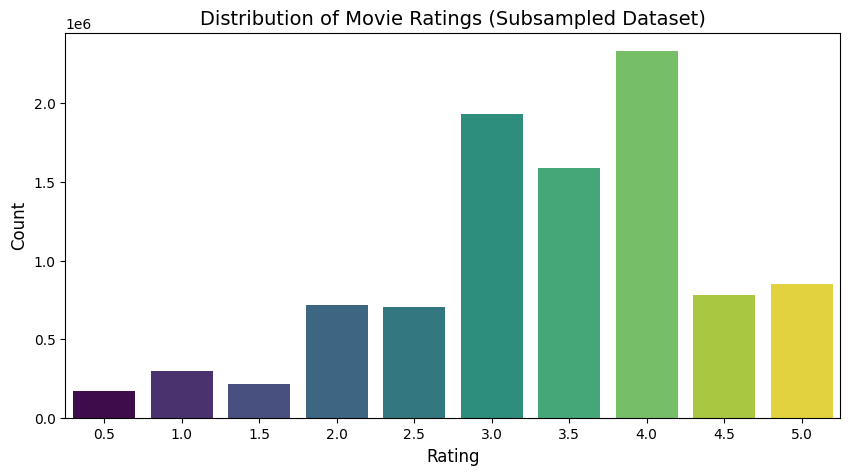

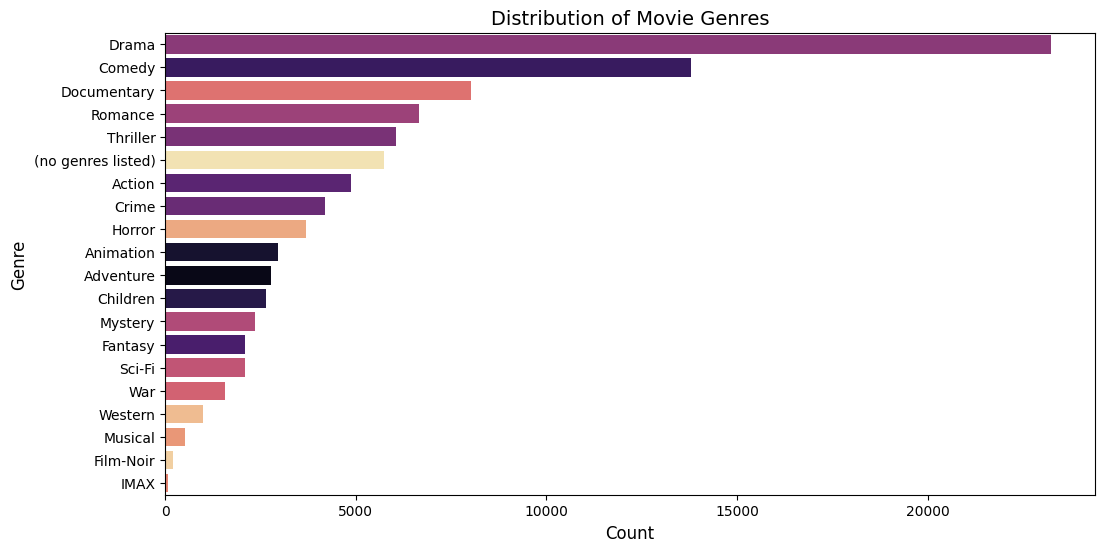

In [96]:
import matplotlib.pyplot as plt

# 1. Plot Distribution of Movie Ratings
plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=rating_sub, palette='viridis', hue='rating', legend=False)
plt.title('Distribution of Movie Ratings (Subsampled Dataset)', fontsize=14)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# 2. Plot Distribution of Movie Genres
genres_split = movies['genres'].str.split('|').explode()
plt.figure(figsize=(12, 6))
sns.countplot(y=genres_split, order=genres_split.value_counts().index, palette='magma', hue=genres_split, legend=False)
plt.title('Distribution of Movie Genres', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

In [97]:
import joblib

svd_model = {
    'U': U,
    'sigma_diag': sigma_diag,
    'Vt': Vt,
    'user_means': user_means,
    'user_id_to_code': user_id_to_code,
    'movie_id_to_code': movie_id_to_code,
    'code_to_movie_id': code_to_movie_id
}

# Save models to disk
joblib.dump(svd_model, 'svd_recommender.joblib')
joblib.dump(Tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_mat, 'tfidf_matrix.joblib')
joblib.dump(movies, 'movies_catalog.joblib')

print("\nAll models successfully exported!")
print("  - svd_recommender.joblib (SVD factors)")
print("  - tfidf_vectorizer.joblib (TF-IDF configuration)")
print("  - tfidf_matrix.joblib (TF-IDF vectors)")
print("  - movies_catalog.joblib (Cleaned movies dataframe)")


All models successfully exported!
  - svd_recommender.joblib (SVD factors)
  - tfidf_vectorizer.joblib (TF-IDF configuration)
  - tfidf_matrix.joblib (TF-IDF vectors)
  - movies_catalog.joblib (Cleaned movies dataframe)
